In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import re
import collections
import torch.nn.functional as F

# Text dataset

In [2]:
!wget -O timemachine.txt http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt

--2026-03-28 22:55:12--  http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt
Resolving d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)... 13.224.43.216
Connecting to d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)|13.224.43.216|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178979 (175K) [text/plain]
Saving to: ‘timemachine.txt’

timemachine.txt     100%[===================>] 174.78K  --.-KB/s    in 0.1s    

2026-03-28 22:55:13 (1.52 MB/s) - ‘timemachine.txt’ saved [178979/178979]



In [3]:
def read_data():
    with open("timemachine.txt", 'r') as f:
        return f.read()

def process_text(text):
    return re.sub("[^A-Za-z]+", ' ', text).lower()

def tokenize(text):
    return list(text)

In [4]:
class Vocab:
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        if isinstance(tokens[0], list):
            tokens = [t for line in tokens for t in line]
        counter = collections.Counter(tokens)
        self.freq_count = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_tokens = list(sorted(set(["<unk>"] + reserved_tokens + [t for t,f in self.freq_count if f>=min_freq])))
        self.tokens_to_idx = {t:i for i,t in enumerate(self.idx_to_tokens)}

    def __len__(self): return len(self.idx_to_tokens)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.tokens_to_idx.get(tokens, self.unk)
        return [self.__getitem__(t) for t in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices) > 1:
            return [self.idx_to_tokens[i] for i in indices]
        return self.idx_to_tokens[indices]

    @property
    def unk(self): return self.tokens_to_idx["<unk>"]

vocab = Vocab(tokenize(process_text(read_data())))
len(vocab)

28

In [5]:
class TextData(torch.utils.data.Dataset):
    def __init__(self, text, num_steps):
        tokens = tokenize(text)
        self.vocab = Vocab(tokens=tokens)
        self.vocab_size = len(self.vocab)
        self.indices = [self.vocab[t] for t in tokens]
        self.array = torch.tensor([self.indices[i:i+num_steps+1] for i in range(len(self.indices) - num_steps)])
        self.X = self.array[:,:-1]
        self.y = self.array[:,1:]

text_data = TextData(process_text(read_data()), 32)

In [6]:
text_data.array

tensor([[21,  9,  6,  ..., 10,  0, 21],
        [ 9,  6,  0,  ...,  0, 21,  9],
        [ 6,  0, 21,  ..., 21,  9,  6],
        ...,
        [20, 21, 10,  ...,  0, 14,  2],
        [21, 10, 13,  ..., 14,  2, 15],
        [10, 13, 13,  ...,  2, 15,  0]])

In [7]:
text_data.X, text_data.y


(tensor([[21,  9,  6,  ...,  0, 10,  0],
         [ 9,  6,  0,  ..., 10,  0, 21],
         [ 6,  0, 21,  ...,  0, 21,  9],
         ...,
         [20, 21, 10,  ...,  7,  0, 14],
         [21, 10, 13,  ...,  0, 14,  2],
         [10, 13, 13,  ..., 14,  2, 15]]),
 tensor([[ 9,  6,  0,  ..., 10,  0, 21],
         [ 6,  0, 21,  ...,  0, 21,  9],
         [ 0, 21, 10,  ..., 21,  9,  6],
         ...,
         [21, 10, 13,  ...,  0, 14,  2],
         [10, 13, 13,  ..., 14,  2, 15],
         [13, 13,  0,  ...,  2, 15,  0]]))

In [8]:
num_train = 10000
num_val = 5000
def get_dataloader(text_data, shuffle, batch_size):
    indices = slice(0, num_train) if shuffle else slice(num_train, num_train+num_val)
    dataset = torch.utils.data.TensorDataset(text_data.X[indices], text_data.y[indices])
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_dataloader = get_dataloader(text_data, True, 1024)
eval_dataloader = get_dataloader(text_data, False, 1024)

# Model

In [9]:
class GRUfromScratch(nn.Module):
    def __init__(self,
                 num_inputs, # d
                 num_hiddens, # h
                 sigma=0.01):
        super(GRUfromScratch, self).__init__()
        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        double = lambda: (init_weight(num_inputs+num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))
        self.W_r, self.b_r = double() # reset gate
        self.W_z, self.b_z = double() # update gate
        self.W_h, self.b_h = double() # candidate hidden state

        self.num_hiddens = num_hiddens
        self.sigma = sigma

    def forward(self, inputs, H=None):
        if H is None:
            H = torch.zeros((inputs.shape[1], self.num_hiddens), device=inputs.device)
        outputs = []
        for X in inputs:
            R = torch.sigmoid(torch.matmul(torch.cat((X,H), dim=1), self.W_r) + self.b_r)
            Z = torch.sigmoid(torch.matmul(torch.cat((X,H), dim=1), self.W_z) + self.b_z)
            H_tilde = torch.tanh(torch.matmul(torch.cat((X,R*H), dim=1), self.W_h) + self.b_h)
            H = Z * H + (1 - Z) * H_tilde
            outputs.append(H)
        return outputs, H

In [10]:
class DeepRNNFromScratch(nn.Module):
  def __init__(self, num_inputs, num_hiddens, num_layers, sigma=0.01):
    super(DeepRNNFromScratch, self).__init__()
    self.rnns = nn.Sequential(
        *[GRUfromScratch(num_inputs=num_inputs if i==0 else num_hiddens,
                          num_hiddens=num_hiddens, sigma=sigma)
        for i in range(num_layers)]
    )
    self.num_layers = num_layers
    self.num_hiddens = num_hiddens
    self.sigma = sigma


  def forward(self, x, states):
    outputs = x
    if states is None: states = [None] * self.num_layers
    for i in range(self.num_layers):
      outputs, states[i] = self.rnns[i](outputs, states[i])
      outputs = torch.stack(outputs, dim=0)
    return outputs, states

In [11]:
class RNNLMfromScratch(nn.Module):
    def __init__(self, rnn, vocab_size):
        super(RNNLMfromScratch, self).__init__()
        self.W_hq = nn.Parameter(torch.randn(rnn.num_hiddens, vocab_size) * rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(vocab_size))
        self.vocab_size = vocab_size
        self.rnn = rnn

    def one_hot(self, x):
        return F.one_hot(x.T, self.vocab_size).type(torch.float32)

    def forward(self, x, state=None):
        embeds = self.one_hot(x)
        rnn_outputs, state = self.rnn(embeds, state)
        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
        return torch.stack(outputs, dim=1), state

In [12]:
batch_size = 1024
num_inputs = 16 # feature dim
num_hiddens = 32
num_steps = 32
num_layers = 2
deep_rnn = DeepRNNFromScratch(num_inputs=text_data.vocab_size, num_hiddens=num_hiddens, num_layers=num_layers)
x = torch.ones((batch_size, num_steps), dtype=torch.int64)
print(x.shape, F.one_hot(x, num_inputs).shape)
model = RNNLMfromScratch(deep_rnn, text_data.vocab_size)
out, _ = model(x)
print(out.shape)


torch.Size([1024, 32]) torch.Size([1024, 32, 16])
torch.Size([1024, 32, 28])


In [13]:
def grad_clip(clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > clip_val:
        for p in params:
            p.grad[:] *= clip_val / norm

In [14]:
def train_deep_rnn(model, max_epochs, clip_val, lr, train_dataloader, eval_dataloader, report_every):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    metrics = {"train_loss": [], "train_ppl": [], "eval_loss": [], "eval_ppl": []}
    criterion = nn.CrossEntropyLoss()

    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr)

    for epoch in range(max_epochs):
        model.train()
        num_instances = 0
        epoch_loss = 0.
        epoch_ppl = 0.
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            logits, _ = model(*batch[:-1])
            logits = logits.reshape(-1, logits.shape[-1])
            loss = criterion(logits, batch[-1].reshape(-1))
            loss.backward()
            grad_clip(clip_val, model)
            optimizer.step()
            epoch_loss += loss.item() * bs
            epoch_ppl += torch.exp(loss).item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_ppl /= num_instances
        metrics["train_loss"].append(epoch_loss)
        metrics["train_ppl"].append(epoch_ppl)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] train_loss: {epoch_loss:.5f}, train_ppl: {epoch_ppl:.5f}")

        model.eval()
        num_instances = 0
        epoch_loss = 0.
        epoch_ppl = 0.
        for step, batch in enumerate(eval_dataloader):
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            with torch.no_grad():
                logits, _ = model(*batch[:-1])
                logits = logits.reshape(-1, logits.shape[-1])
                loss = criterion(logits, batch[-1].reshape(-1))
                epoch_loss += loss.item() * bs
                epoch_ppl += torch.exp(loss).item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_ppl /= num_instances
        metrics["eval_loss"].append(epoch_loss)
        metrics["eval_ppl"].append(epoch_ppl)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] eval_loss: {epoch_loss:.5f}, eval_ppl: {epoch_ppl:.5f}")

    return metrics


In [15]:
vocab_size = text_data.vocab_size
deep_rnn = DeepRNNFromScratch(num_inputs=vocab_size, num_hiddens=32, num_layers=2)
model = RNNLMfromScratch(rnn=deep_rnn, vocab_size=vocab_size)
metrics = train_deep_rnn(model, max_epochs=100, clip_val=1, lr=4, train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, report_every=10)

[0/100] train_loss: 3.02113, train_ppl: 20.70859
[0/100] eval_loss: 2.87280, eval_ppl: 17.69163
[10/100] train_loss: 2.84329, train_ppl: 17.17244
[10/100] eval_loss: 2.81924, eval_ppl: 16.77011
[20/100] train_loss: 2.83805, train_ppl: 17.08252
[20/100] eval_loss: 2.81459, eval_ppl: 16.69170
[30/100] train_loss: 2.83752, train_ppl: 17.07342
[30/100] eval_loss: 2.81290, eval_ppl: 16.66393
[40/100] train_loss: 2.66705, train_ppl: 14.39855
[40/100] eval_loss: 2.62822, eval_ppl: 13.86236
[50/100] train_loss: 2.39411, train_ppl: 10.95940
[50/100] eval_loss: 2.35687, eval_ppl: 10.56750
[60/100] train_loss: 2.24087, train_ppl: 9.40329
[60/100] eval_loss: 2.21139, eval_ppl: 9.13792
[70/100] train_loss: 2.09240, train_ppl: 8.10495
[70/100] eval_loss: 2.12392, eval_ppl: 8.37360
[80/100] train_loss: 1.98103, train_ppl: 7.25119
[80/100] eval_loss: 2.08740, eval_ppl: 8.08410
[90/100] train_loss: 1.83256, train_ppl: 6.25143
[90/100] eval_loss: 2.00966, eval_ppl: 7.48273


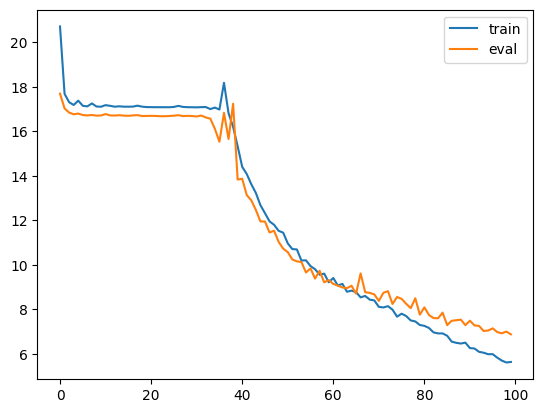

In [16]:
plt.plot(metrics["train_ppl"], label="train")
plt.plot(metrics["eval_ppl"], label="eval")
plt.legend(); plt.show()

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def predict(text, num_steps, vocab, model, device):
    state, outputs = None, [vocab[text[0]]]
    model.eval()
    with torch.no_grad():
        for i in range(num_steps+len(text)-1):
            if i < len(text) - 1:
                outputs.append(vocab[text[i+1]])
            else:
                logits, state = model(torch.tensor([[outputs[-1]]], device=device), state)
                pred_id = logits.argmax(dim=-1).reshape(1)
                outputs.append(int(pred_id))
        return ''.join(vocab.to_tokens(outputs))

In [19]:
predict("it has", 20, text_data.vocab, model, device=device)

'it has of the time travell'

In [20]:
class DeepRNN(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_layers):
        super(DeepRNN, self).__init__()
        self.rnn = nn.GRU(input_size=num_inputs, hidden_size=num_hiddens, num_layers=num_layers)
        self.num_hiddens = num_hiddens

    def forward(self, x, H_C=None):
        return self.rnn(x, H_C)

In [21]:
class RNNLM(nn.Module):
    def __init__(self, rnn, vocab_size):
        super(RNNLM, self).__init__()
        self.linear = nn.Linear(in_features=rnn.num_hiddens, out_features=vocab_size)
        self.vocab_size = vocab_size
        self.rnn = rnn

    def one_hot(self, x):
        return F.one_hot(x.T, self.vocab_size).type(torch.float32)

    def forward(self, x, state=None):
        embeds = self.one_hot(x)
        rnn_outputs, state = self.rnn(embeds, state)
        outputs = self.linear(rnn_outputs).swapaxes(0,1)
        return outputs, state

In [22]:
vocab_size = text_data.vocab_size
deep_rnn = DeepRNN(num_inputs=vocab_size, num_hiddens=32, num_layers=2)
model = RNNLM(rnn=deep_rnn, vocab_size=vocab_size)
metrics = train_deep_rnn(model, max_epochs=100, clip_val=1, lr=2, train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, report_every=10)

[0/100] train_loss: 3.00021, train_ppl: 20.34536
[0/100] eval_loss: 2.86797, eval_ppl: 17.60557
[10/100] train_loss: 2.52017, train_ppl: 12.43277
[10/100] eval_loss: 2.46308, eval_ppl: 11.74583
[20/100] train_loss: 2.29654, train_ppl: 9.94149
[20/100] eval_loss: 2.25596, eval_ppl: 9.55191
[30/100] train_loss: 2.10500, train_ppl: 8.20758
[30/100] eval_loss: 2.13808, eval_ppl: 8.50004
[40/100] train_loss: 1.94631, train_ppl: 7.00355
[40/100] eval_loss: 2.02846, eval_ppl: 7.61606
[50/100] train_loss: 1.82536, train_ppl: 6.20584
[50/100] eval_loss: 1.93692, eval_ppl: 6.95323
[60/100] train_loss: 1.72311, train_ppl: 5.60238
[60/100] eval_loss: 1.89381, eval_ppl: 6.65840
[70/100] train_loss: 1.64027, train_ppl: 5.15741
[70/100] eval_loss: 1.85160, eval_ppl: 6.38379
[80/100] train_loss: 1.55143, train_ppl: 4.71856
[80/100] eval_loss: 1.85362, eval_ppl: 6.39946
[90/100] train_loss: 1.48265, train_ppl: 4.40554
[90/100] eval_loss: 1.84296, eval_ppl: 6.33112


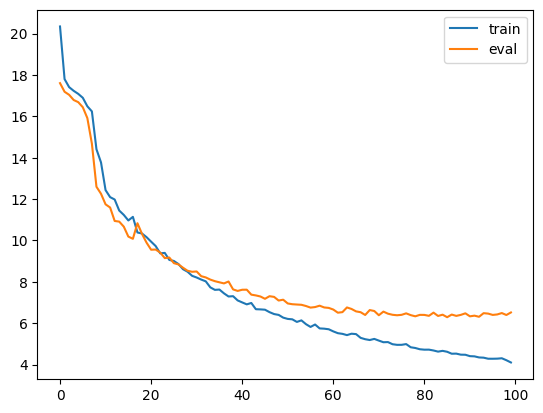

In [23]:
plt.plot(metrics["train_ppl"], label="train")
plt.plot(metrics["eval_ppl"], label="eval")
plt.legend(); plt.show()

In [25]:
predict("it has", 20, text_data.vocab, model, device=device)

'it has and the time travel'